# 評估目標

::: {.callout-tip}

投影片操作：**Alt + 點擊** 可縮放任何圖片/表格（reveal.js zoom）；`O` 鍵總覽、`F` 全螢幕。

:::

**研究提問**：是否存在「機器學習配對 + 深度學習交易」策略，績效優於 SSD/DTW 距離法基準，且年化報酬 $\ge 2\%$？

資料來源：`results/result.db` `strategy_summaries`（現役 8 策略 × 參數網格）。

**資料處理原則**：

- `result.db` 保留已封存策略的歷史結果（封存不刪數據）——本筆記本**只比較現役策略**，以白名單過濾
- 同一網格鍵若因重跑產生多筆，保留最新一筆（防禦性去重）
- DRL-THR 系策略未固定隨機種子，單次數值為隨機變數；跨輪分布見 `results/drl_variance_runs.csv`


In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = ["Microsoft JhengHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams.update({"font.size": 14, "figure.dpi": 110})

# 現役 8 策略白名單（strategies/config.py strategies_raw_all，2026-07-06 陣容）
ACTIVE_METHODS = [
    "SSD (Basic)",
    "SSD (Rolling)",
    "DTW (Paper-Fixed)",
    "SSD-DTW-PCA (Paper-Fixed)",
    "SSD (Rolling-DRL-THR)",
    "HDBSCAN (Cluster-SSD-DTW-PCA-PCA5)",
    "Agglomerative (Fundamentals)",
    "Agglomerative (Fundamentals-DRL-THR)",
]

db = next(p / "results" / "result.db" for p in [Path.cwd(), *Path.cwd().parents] if (p / "results" / "result.db").exists())
raw_df = pd.read_sql("SELECT * FROM strategy_summaries", sqlite3.connect(f"file:{db}?mode=ro", uri=True))

n_archived = (~raw_df["METHOD"].isin(ACTIVE_METHODS)).sum()
df = raw_df[raw_df["METHOD"].isin(ACTIVE_METHODS)].copy()

# 防禦性去重：同一網格鍵保留最後寫入的一筆
_grid_key = ["METHOD", "TOP N", "STOP LOSS %", "MAX SEC %", "ENTRY Z", "DYN Z NUM"]
n_before = len(df)
df = df.drop_duplicates(subset=_grid_key, keep="last").reset_index(drop=True)

missing = sorted(set(ACTIVE_METHODS) - set(df["METHOD"].unique()))
print(f"{db}")
print(f"現役網格結果 {len(df)} 筆（去重移除 {n_before - len(df)} 筆）｜排除封存策略殘留 {n_archived} 筆")
print(f"現役 {df['METHOD'].nunique()}/{len(ACTIVE_METHODS)} 策略有數據" + (f"｜缺：{missing}（回測尚未執行）" if missing else ""))


C:\Clark\YZU\Papper\Code\results\result.db
現役網格結果 150 筆（去重移除 0 筆）｜排除封存策略殘留 45 筆
現役 8/8 策略有數據


## 各策略最佳 Sharpe 組合


In [2]:
cols = ["METHOD", "TRADE_METHOD", "TOP N", "STOP LOSS %", "Sharpe_Raw", "Ann_Ret_Raw", "MDD_Raw", "Win_Rate"]
best_sharpe = (df.loc[df.groupby("METHOD")["Sharpe_Raw"].idxmax(), cols]
                 .sort_values("Sharpe_Raw", ascending=False).reset_index(drop=True))
best_sharpe.style.format({"Sharpe_Raw": "{:.3f}", "Ann_Ret_Raw": "{:.2%}", "MDD_Raw": "{:.2%}", "Win_Rate": "{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Win_Rate
0,SSD-DTW-PCA (Paper-Fixed),Z-Score,Top 3,0%,0.558,2.11%,-9.38%,32.6%
1,SSD (Rolling-DRL-THR),DRL,Top 10,0%,0.392,0.82%,-6.26%,35.8%
2,Agglomerative (Fundamentals-DRL-THR),DRL,Top 1,5%,0.348,2.89%,-23.83%,45.4%
3,Agglomerative (Fundamentals),Z-Score,Top 1,15%,0.347,2.17%,-17.17%,35.1%
4,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5),Z-Score,Top 10,0%,0.294,0.90%,-11.69%,33.9%
5,DTW (Paper-Fixed),Z-Score,Top 3,0%,0.271,1.06%,-11.92%,32.8%
6,SSD (Rolling),Z-Score,Top 1,0%,0.262,2.30%,-23.61%,34.4%
7,SSD (Basic),Z-Score,Top 1,0%,0.160,0.49%,-13.95%,38.1%


## 各策略最佳年化報酬組合


In [3]:
best_ret = (df.loc[df.groupby("METHOD")["Ann_Ret_Raw"].idxmax(), cols]
              .sort_values("Ann_Ret_Raw", ascending=False).reset_index(drop=True))
best_ret.style.format({"Sharpe_Raw": "{:.3f}", "Ann_Ret_Raw": "{:.2%}", "MDD_Raw": "{:.2%}", "Win_Rate": "{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Win_Rate
0,Agglomerative (Fundamentals-DRL-THR),DRL,Top 1,5%,0.348,2.89%,-23.83%,45.4%
1,Agglomerative (Fundamentals),Z-Score,Top 1,0%,0.325,2.70%,-23.80%,35.6%
2,SSD (Rolling-DRL-THR),DRL,Top 1,0%,0.277,2.44%,-23.61%,43.0%
3,SSD (Rolling),Z-Score,Top 1,0%,0.262,2.30%,-23.61%,34.4%
4,SSD-DTW-PCA (Paper-Fixed),Z-Score,Top 3,0%,0.558,2.11%,-9.38%,32.6%
5,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5),Z-Score,Top 1,15%,0.213,1.08%,-26.38%,33.9%
6,DTW (Paper-Fixed),Z-Score,Top 3,0%,0.271,1.06%,-11.92%,32.8%
7,SSD (Basic),Z-Score,Top 1,0%,0.160,0.49%,-13.95%,38.1%


## 最佳 Sharpe 長條圖


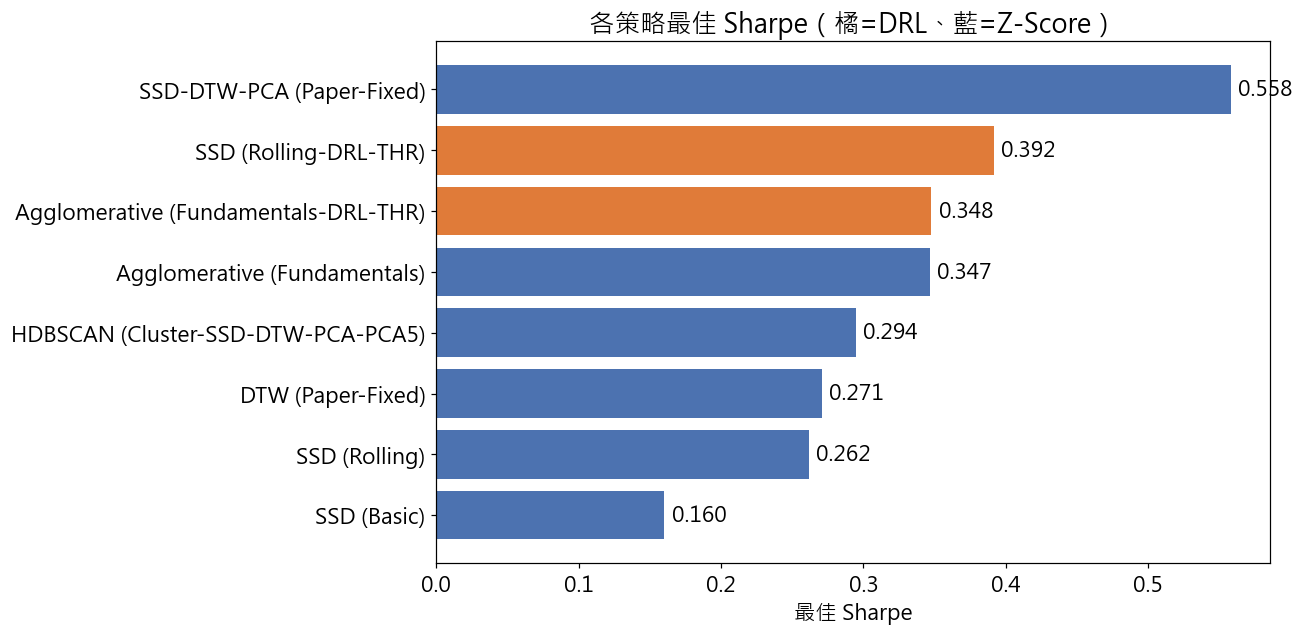

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
d = best_sharpe.sort_values("Sharpe_Raw")
colors = ["#e07b39" if t == "DRL" else "#4c72b0" for t in d["TRADE_METHOD"]]
ax.barh(d["METHOD"], d["Sharpe_Raw"], color=colors)
ax.set_xlabel("最佳 Sharpe"); ax.set_title("各策略最佳 Sharpe（橘=DRL、藍=Z-Score）")
for i, v in enumerate(d["Sharpe_Raw"]): ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()


## 最佳年化報酬長條圖（2% 門檻線）


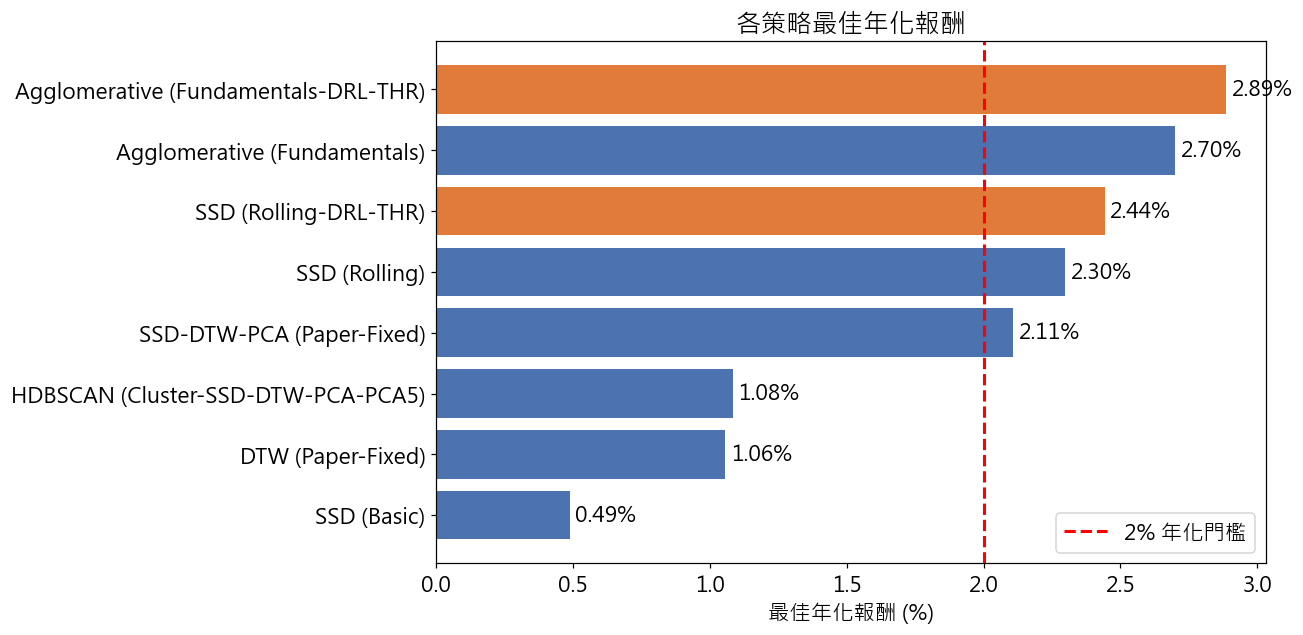

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
d = best_ret.sort_values("Ann_Ret_Raw")
colors = ["#e07b39" if t == "DRL" else "#4c72b0" for t in d["TRADE_METHOD"]]
ax.barh(d["METHOD"], d["Ann_Ret_Raw"] * 100, color=colors)
ax.axvline(2.0, color="red", ls="--", lw=2, label="2% 年化門檻")
ax.set_xlabel("最佳年化報酬 (%)"); ax.set_title("各策略最佳年化報酬"); ax.legend()
for i, v in enumerate(d["Ann_Ret_Raw"] * 100): ax.text(v + 0.02, i, f"{v:.2f}%", va="center")
plt.tight_layout(); plt.show()


## Sharpe × 年化報酬散佈（全網格）


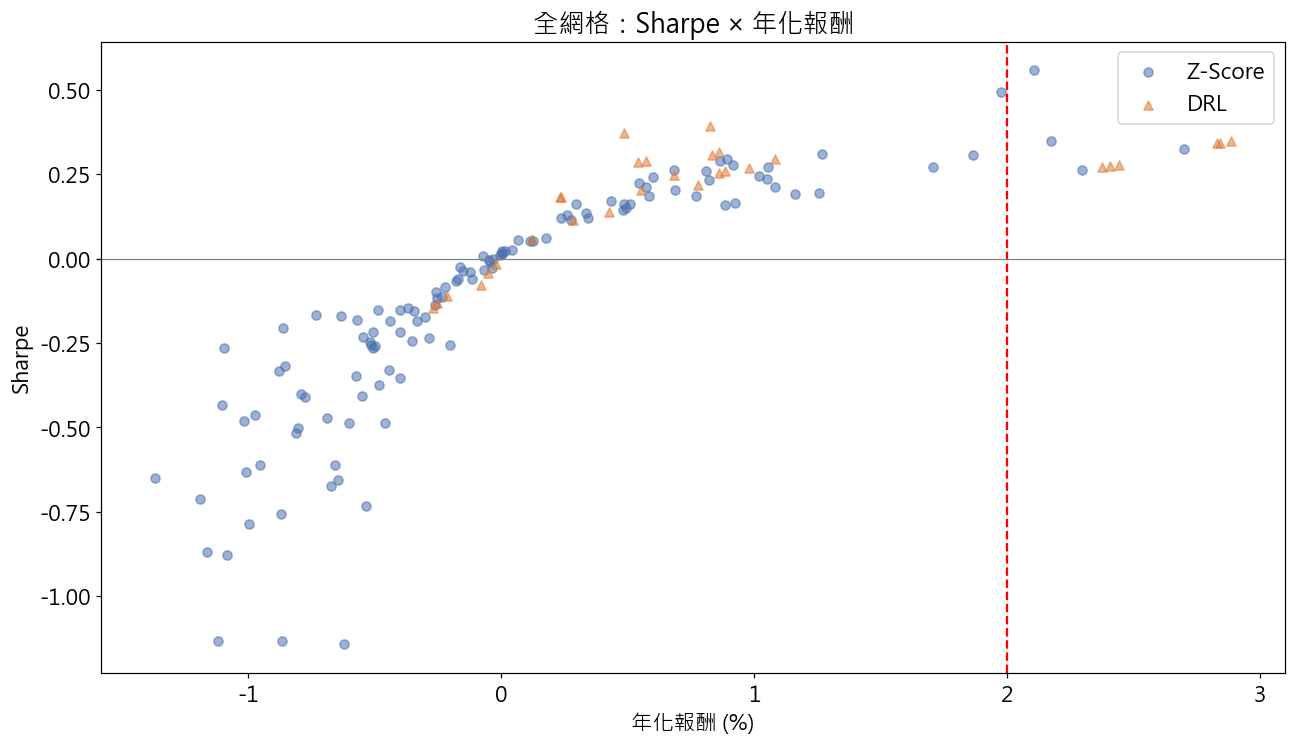

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for tm, c, m in [("Z-Score", "#4c72b0", "o"), ("DRL", "#e07b39", "^")]:
    sub = df[df["TRADE_METHOD"] == tm]
    ax.scatter(sub["Ann_Ret_Raw"] * 100, sub["Sharpe_Raw"], c=c, marker=m, alpha=0.55, label=tm)
ax.axvline(2.0, color="red", ls="--", lw=1.5); ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("年化報酬 (%)"); ax.set_ylabel("Sharpe"); ax.set_title("全網格：Sharpe × 年化報酬")
ax.legend(); plt.tight_layout(); plt.show()


## Z-Score 基準 vs DRL 疊加（配對比較）

現役 DRL-THR 策略各自借用對應 Z-Score 策略的形成期配對——唯一變因是交易決策邏輯。
DRL 數值為單次訓練結果，跨輪分布見 `results/drl_variance_summary.csv`。


In [7]:
pairs = [("SSD (Rolling)", "SSD (Rolling-DRL-THR)"),
         ("Agglomerative (Fundamentals)", "Agglomerative (Fundamentals-DRL-THR)")]
rows = []
for base, drl in pairs:
    b, d_ = df[df["METHOD"] == base], df[df["METHOD"] == drl]
    if b.empty or d_.empty:
        continue
    rows.append({"形成底": base,
                 "Sharpe (Z)": b["Sharpe_Raw"].max(), "Sharpe (DRL)": d_["Sharpe_Raw"].max(),
                 "ΔSharpe": d_["Sharpe_Raw"].max() - b["Sharpe_Raw"].max(),
                 "年化 (Z)": b["Ann_Ret_Raw"].max(), "年化 (DRL)": d_["Ann_Ret_Raw"].max(),
                 "Δ年化": d_["Ann_Ret_Raw"].max() - b["Ann_Ret_Raw"].max()})
pd.DataFrame(rows).style.format({"Sharpe (Z)": "{:.3f}", "Sharpe (DRL)": "{:.3f}", "ΔSharpe": "{:+.3f}",
                                  "年化 (Z)": "{:.2%}", "年化 (DRL)": "{:.2%}", "Δ年化": "{:+.2%}"})


,形成底,Sharpe (Z),Sharpe (DRL),ΔSharpe,年化 (Z),年化 (DRL),Δ年化
0,SSD (Rolling),0.262,0.392,+0.130,2.30%,2.44%,+0.14%
1,Agglomerative (Fundamentals),0.347,0.348,+0.001,2.70%,2.89%,+0.19%


## 達標檢核（動態產生）


In [8]:
passed = best_ret[best_ret["Ann_Ret_Raw"] >= 0.02].copy()
print("跨過 2% 年化門檻的策略（依年化排序）：")
for _, r in passed.iterrows():
    print(f"  {r['METHOD']:<45s} 年化 {r['Ann_Ret_Raw']:.2%}｜Sharpe {r['Sharpe_Raw']:.3f}｜{r['TRADE_METHOD']}")
top_sharpe = best_sharpe.iloc[0]
print(f"\n全組最高 Sharpe：{top_sharpe['METHOD']}（{top_sharpe['Sharpe_Raw']:.3f}，年化 {top_sharpe['Ann_Ret_Raw']:.2%}）")


跨過 2% 年化門檻的策略（依年化排序）：
  Agglomerative (Fundamentals-DRL-THR)          年化 2.89%｜Sharpe 0.348｜DRL
  Agglomerative (Fundamentals)                  年化 2.70%｜Sharpe 0.325｜Z-Score
  SSD (Rolling-DRL-THR)                         年化 2.44%｜Sharpe 0.277｜DRL
  SSD (Rolling)                                 年化 2.30%｜Sharpe 0.262｜Z-Score
  SSD-DTW-PCA (Paper-Fixed)                     年化 2.11%｜Sharpe 0.558｜Z-Score

全組最高 Sharpe：SSD-DTW-PCA (Paper-Fixed)（0.558，年化 2.11%）


## DRL-THR 訓練變異數：五輪獨立重跑分布

`strategy_summaries` 只保留最後一輪的單次結果；DRL-THR 未固定隨機種子，
下列統計來自 `results/drl_variance_runs.csv`（`run_drl_variance.py` 五輪完整網格重跑），
**這才是 DRL 策略應引用的正式數字（中位數 ± 範圍）**。


In [9]:
var_csv = db.parent / "drl_variance_runs.csv"
runs = pd.read_csv(var_csv)
runs_active = runs[runs["METHOD"].isin(ACTIVE_METHODS)].copy()

per_run = (runs_active.groupby(["METHOD", "run_id"])
           .agg(best_sharpe=("Sharpe_Raw", "max"), best_ann=("Ann_Ret_Raw", "max"))
           .reset_index())
summary = (per_run.groupby("METHOD")
           .agg(輪數=("run_id", "nunique"),
                Sharpe_中位=("best_sharpe", "median"), Sharpe_最小=("best_sharpe", "min"), Sharpe_最大=("best_sharpe", "max"),
                年化_中位=("best_ann", "median"), 年化_最小=("best_ann", "min"), 年化_最大=("best_ann", "max"))
           .reset_index())
summary.style.format({"Sharpe_中位": "{:.3f}", "Sharpe_最小": "{:.3f}", "Sharpe_最大": "{:.3f}",
                      "年化_中位": "{:.2%}", "年化_最小": "{:.2%}", "年化_最大": "{:.2%}"})


,METHOD,輪數,Sharpe_中位,Sharpe_最小,Sharpe_最大,年化_中位,年化_最小,年化_最大
0,Agglomerative (Fundamentals-DRL-THR),5,0.354,0.347,0.356,2.95%,2.89%,2.96%
1,SSD (Rolling-DRL-THR),5,0.377,0.340,0.425,2.55%,2.44%,2.72%


C:\Users\og801\AppData\Local\Temp\ipykernel_71768\1659293329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, widths=0.5)
C:\Users\og801\AppData\Local\Temp\ipykernel_71768\1659293329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, widths=0.5)


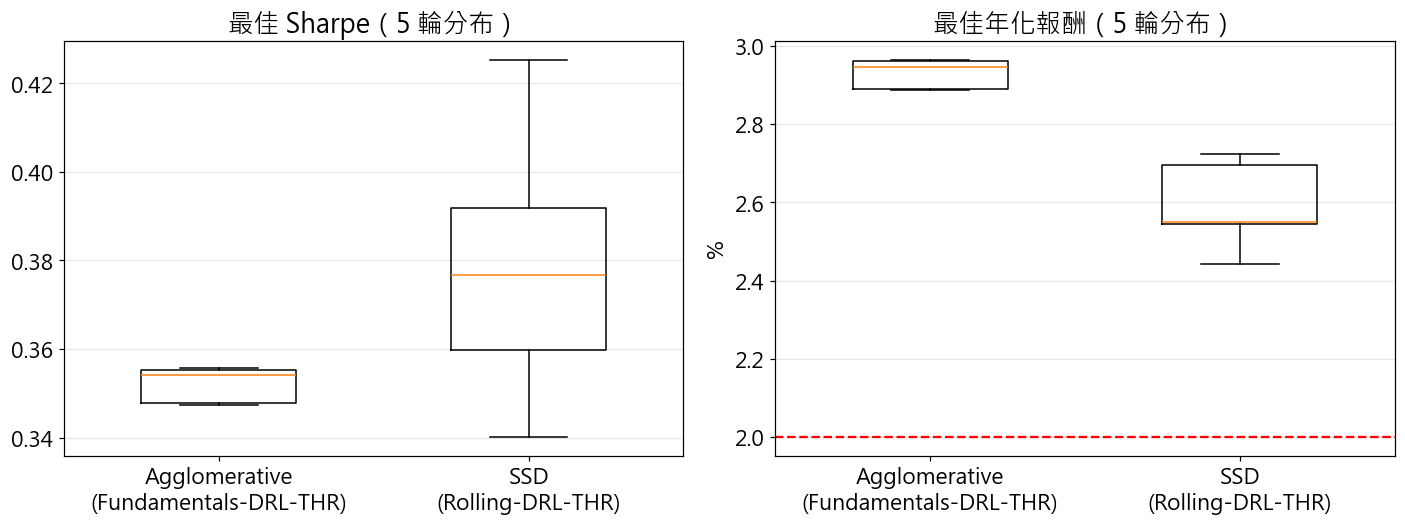

單輪（result.db 最新一輪）數值落在上述分布範圍內即屬正常重訓波動


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
methods = sorted(per_run["METHOD"].unique())
labels = [m.replace(" (", chr(10) + "(") for m in methods]
for ax, col, title in [(axes[0], "best_sharpe", "最佳 Sharpe（5 輪分布）"),
                        (axes[1], "best_ann", "最佳年化報酬（5 輪分布）")]:
    data = [per_run[per_run["METHOD"] == m][col] * (100 if col == "best_ann" else 1) for m in methods]
    ax.boxplot(data, labels=labels, widths=0.5)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
axes[1].axhline(2.0, color="red", ls="--", lw=1.5)
axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()
print("單輪（result.db 最新一輪）數值落在上述分布範圍內即屬正常重訓波動")


## 解讀注意事項 {.smaller}

- **SSD (Basic)**：2026-07-06 起為 Gatev/Zhu 論文復刻版（全市場、純距離、無統計過濾）；
  此日期前的歷史數據為舊版演算法（同產業＋三道過濾），不可跨版本比較
- **Agglomerative 系**：基本面為單一時點靜態快照，存在前視偏誤限制（見形成期筆記本）
- **DRL-THR 系**：未固定隨機種子，單次數值有 ±0.1 Sharpe 級別的重訓波動；
  比較應以「Z-Score 基準 → DRL 疊加」的相對提升方向為準，絕對數值以
  `drl_variance_summary.csv` 的中位數±範圍為準
- 已封存策略（HDBSCAN 15 維系、PCA-Loadings 系、ML Pair Quality 等）的歷史結果
  仍保留於 `result.db`，本筆記本以白名單排除；需要時可修改 `ACTIVE_METHODS` 調閱
